# Target summary

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [13]:
def find_repo_root():
    path = Path.cwd().resolve()

    for parent in [path, *path.parents]:
        if (parent / "data" / "allstate_claims_data.csv").exists():
            return parent

    raise FileNotFoundError("Could not find data/allstate_claims_data.csv")


REPO_ROOT = find_repo_root()
DATA_PATH = REPO_ROOT / "data" / "allstate_claims_data.csv"

EXPECTED_SIZE = 70_025_339
EXPECTED_SHAPE = (188_318, 132)

EXPECTED_HEADER = (
    ["id"]
    + [f"cat{i}" for i in range(1, 117)]
    + [f"cont{i}" for i in range(1, 15)]
    + ["loss"]
)

print(DATA_PATH.relative_to(REPO_ROOT))
df = pd.read_csv(DATA_PATH)

data/allstate_claims_data.csv


In [14]:

loss = df['loss']

summary = {
    'count': loss.count(),
    'mean': loss.mean(),
    'median': loss.median(),
    'std': loss.std(),
    'min': loss.min(),
    'max': loss.max(),
    'skew': loss.skew(),
}
for p in [25, 50, 75, 90, 95, 99]:
    summary[f'p{p}'] = np.percentile(loss, p)

summary_table = pd.Series(summary)
summary_table.to_csv('target_summary.csv')
summary_table

count     188318.000000
mean        3037.337686
median      2115.570000
std         2904.086186
min            0.670000
max       121012.250000
skew           3.794958
p25         1204.460000
p50         2115.570000
p75         3864.045000
p90         6401.743000
p95         8508.536500
p99        13981.203000
dtype: float64

# Plots

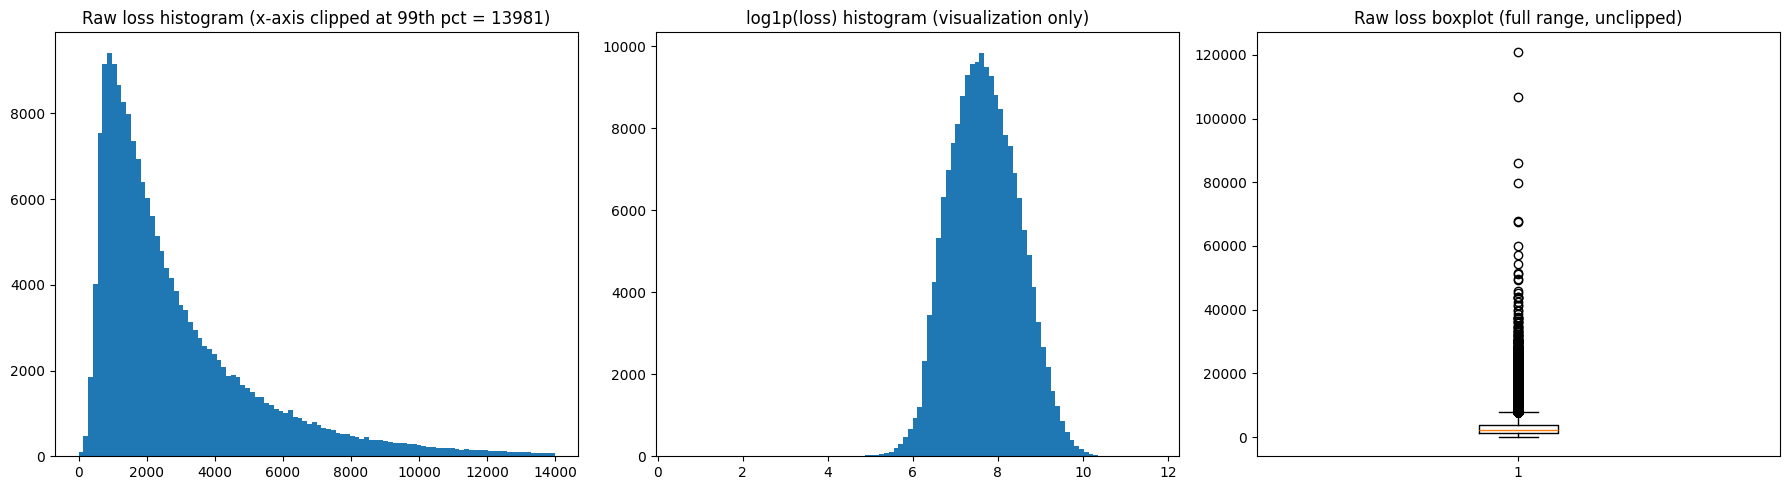

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# raw histogram
p99 = np.percentile(loss, 99)
axes[0].hist(loss, bins=100, range=(0, p99))
axes[0].set_title(f'Raw loss histogram (x-axis clipped at 99th pct = {p99:.0f})')

# log1p histogram
axes[1].hist(np.log1p(loss), bins=100)
axes[1].set_title('log1p(loss) histogram (visualization only)')

# boxplot
axes[2].boxplot(loss)
axes[2].set_title('Raw loss boxplot (full range, unclipped)')

plt.tight_layout()
plt.savefig('target_views.png', dpi=120)